<a href="https://colab.research.google.com/github/RennyDanilo2023/VINOCUNGA-PILLAJO-2526---MINERIA-DE-DATOS-A-/blob/main/Modelo_Prediccion_Calidad_Cafe_VINOCUNGA_PILLAJO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Librerías para análisis de datos
import pandas as pd
import numpy as np

# Librerías para gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de machine learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Guardar modelo
import joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ruta = "/content/drive/MyDrive/Cafe-Datos-1000-sintetico.xlsx"

df = pd.read_excel(ruta)

df.head()

,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,Producer,Number of Bags,...,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",Diego Samuel Bermudez,1,...,8933,118,0,0,green,3,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,曾福森,1,...,8758,105,0,0,blue-green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,WU TAO CHI,19,...,8742,104,0,0,yellowish,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
3,Costa Rica,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900,"Los Santos,Tarrazu",Santa Maria de Dota,1,...,8717,118,0,0,green,0,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
4,Colombia,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1850-2100,"Popayan,Cauca",Camilo Merizalde,2,...,8708,116,0,2,yellow-green,2,"March 5th, 2024",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Country of Origin      207 non-null    object
 1   Farm Name              205 non-null    object
 2   Lot Number             206 non-null    object
 3   Mill                   204 non-null    object
 4   ICO Number             75 non-null     object
 5   Company                207 non-null    object
 6   Altitude               206 non-null    object
 7   Region                 205 non-null    object
 8   Producer               206 non-null    object
 9   Number of Bags         207 non-null    int64 
 10  Bag Weight             207 non-null    object
 11  In-Country Partner     207 non-null    object
 12  Harvest Year           207 non-null    object
 13  Grading Date           207 non-null    object
 14  Owner                  207 non-null    object
 15  Variety                

In [ ]:
df.describe()

,Number of Bags,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean Cup,Sweetness,Overall,Defects,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Category Two Defects
count,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.0,207.0,207.000000,207.0,207.000000,207.000000,207.000000,207.000000,207.000000
mean,155.449275,664.280193,642.299517,657.149758,642.289855,651.048309,628.318841,107.729469,100.0,100.0,627.028986,0.0,6773.917874,96.265700,0.135266,0.690821,2.251208
std,244.484868,252.782263,273.695187,245.725243,269.853040,256.191709,275.915273,78.511976,0.0,0.0,279.453817,0.0,3097.021615,33.369685,0.592070,1.686918,2.950183
min,1.000000,65.000000,75.000000,70.000000,70.000000,70.000000,70.000000,100.000000,100.0,100.0,70.000000,0.0,780.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,733.000000,725.000000,725.000000,733.000000,733.000000,725.000000,100.000000,100.0,100.0,717.000000,0.0,8062.500000,97.000000,0.000000,0.000000,0.000000
50%,14.000000,767.000000,767.000000,758.000000,767.000000,758.000000,767.000000,100.000000,100.0,100.0,758.000000,0.0,8325.000000,106.000000,0.000000,0.000000,1.000000
75%,275.000000,783.000000,783.000000,775.000000,783.000000,775.000000,775.000000,100.000000,100.0,100.0,783.000000,0.0,8458.000000,115.000000,0.000000,1.000000,3.000000
max,2240.000000,858.000000,842.000000,842.000000,858.000000,825.000000,842.000000,933.000000,100.0,100.0,858.000000,0.0,8933.000000,135.000000,5.000000,12.000000,16.000000


In [ ]:
df.isnull().sum()

,0
Country of Origin,0
Farm Name,2
Lot Number,1
Mill,3
ICO Number,132
Company,0
Altitude,1
Region,2
Producer,1
Number of Bags,0


In [ ]:
df.columns

Index(['Country of Origin', 'Farm Name', 'Lot Number', 'Mill', 'ICO Number',
       'Company', 'Altitude', 'Region', 'Producer', 'Number of Bags',
       'Bag Weight', 'In-Country Partner', 'Harvest Year', 'Grading Date',
       'Owner', 'Variety', 'Status', 'Processing Method', 'Aroma', 'Flavor',
       'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup',
       'Sweetness', 'Overall', 'Defects', 'Total Cup Points',
       'Moisture Percentage', 'Category One Defects', 'Quakers', 'Color',
       'Category Two Defects', 'Expiration', 'Certification Body',
       'Certification Address', 'Certification Contact'],
      dtype='object')

In [ ]:
df.head()

,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,Producer,Number of Bags,...,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",Diego Samuel Bermudez,1,...,8933,118,0,0,green,3,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,曾福森,1,...,8758,105,0,0,blue-green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,WU TAO CHI,19,...,8742,104,0,0,yellowish,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
3,Costa Rica,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900,"Los Santos,Tarrazu",Santa Maria de Dota,1,...,8717,118,0,0,green,0,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
4,Colombia,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1850-2100,"Popayan,Cauca",Camilo Merizalde,2,...,8708,116,0,2,yellow-green,2,"March 5th, 2024",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901


In [ ]:
def clasificar_cafe(x):
    if x >= 85:
        return 'Excelente'
    elif x >= 80:
        return 'Muy bueno'
    elif x >= 75:
        return 'Bueno'
    else:
        return 'Comercial'

df['Categoria'] = df['Total Cup Points'].apply(clasificar_cafe)

In [ ]:
df[['Total Cup Points','Categoria']].head()

,Total Cup Points,Categoria
0,8933,Excelente
1,8758,Excelente
2,8742,Excelente
3,8717,Excelente
4,8708,Excelente


In [ ]:
features = [
    'Aroma',
    'Flavor',
    'Aftertaste',
    'Acidity',
    'Body',
    'Balance',
    'Uniformity',
    'Clean Cup',
    'Sweetness',
    'Overall',
    'Moisture Percentage'
]

X = df[features]

y = df['Categoria']

In [ ]:
# Reemplazar valores nulos por promedio
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
df['Total_Cup_Points_Real'] = df['Total Cup Points'] / 100

In [ ]:
def clasificar_cafe(x):
    if x >= 85:
        return 'Excelente'
    elif x >= 80:
        return 'Muy bueno'
    elif x >= 75:
        return 'Bueno'
    else:
        return 'Comercial'

df['Categoria'] = df['Total_Cup_Points_Real'].apply(clasificar_cafe)

In [ ]:
df['Categoria'].value_counts()

,count
Categoria,
Muy bueno,124
Comercial,44
Excelente,37
Bueno,2


In [ ]:
df[['Total Cup Points', 'Total_Cup_Points_Real', 'Categoria']].head(10)

,Total Cup Points,Total_Cup_Points_Real,Categoria
0,8933,89.33,Excelente
1,8758,87.58,Excelente
2,8742,87.42,Excelente
3,8717,87.17,Excelente
4,8708,87.08,Excelente
5,870,8.70,Comercial
6,8692,86.92,Excelente
7,8675,86.75,Excelente
8,8667,86.67,Excelente
9,865,8.65,Comercial


In [ ]:
features = [
    'Aroma',
    'Flavor',
    'Aftertaste',
    'Acidity',
    'Body',
    'Balance',
    'Uniformity',
    'Clean Cup',
    'Sweetness',
    'Overall',
    'Moisture Percentage'
]

X = df[features]
y = df['Categoria']

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Datos entrenamiento:", X_train.shape)
print("Datos prueba:", X_test.shape)

Datos entrenamiento: (165, 11)
Datos prueba: (42, 11)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

modelo_arbol = DecisionTreeClassifier(random_state=42)
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rl = LogisticRegression(max_iter=1000)

modelo_arbol.fit(X_train, y_train)
modelo_rf.fit(X_train, y_train)
modelo_rl.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score

pred_arbol = modelo_arbol.predict(X_test)
pred_rf = modelo_rf.predict(X_test)
pred_rl = modelo_rl.predict(X_test)

print("Accuracy Árbol:", accuracy_score(y_test, pred_arbol))
print("Accuracy Random Forest:", accuracy_score(y_test, pred_rf))
print("Accuracy Regresión Logística:", accuracy_score(y_test, pred_rl))

Accuracy Árbol: 0.5238095238095238
Accuracy Random Forest: 0.7380952380952381
Accuracy Regresión Logística: 0.5952380952380952


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(modelo_rf, X, y, cv=5)

print("Validación cruzada:", scores)

print("Promedio validación cruzada:", scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Validación cruzada: [0.4047619  0.69047619 0.70731707 0.65853659 0.58536585]
Promedio validación cruzada: 0.6092915214866435


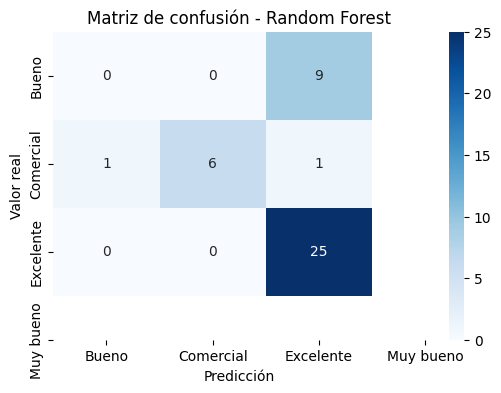

              precision    recall  f1-score   support

   Comercial       0.00      0.00      0.00         9
   Excelente       1.00      0.75      0.86         8
   Muy bueno       0.71      1.00      0.83        25

    accuracy                           0.74        42
   macro avg       0.57      0.58      0.56        42
weighted avg       0.62      0.74      0.66        42



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_rf.classes_,
            yticklabels=modelo_rf.classes_)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Random Forest")
plt.show()

print(classification_report(y_test, pred_rf))

In [ ]:
import joblib
joblib.dump(modelo_rf, '/content/drive/MyDrive/modelo_cafe.pkl')

['/content/drive/MyDrive/modelo_cafe.pkl']